In [18]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.patches import Circle


In [19]:
Myr_per_Nbody = 0.36627254517014160E+03/ 0.15200000000000000E+03
source = '/cosma5/data/durham/dc-pick2/simulations'
hyades = source + '/Hyades'
hyades

'/cosma5/data/durham/dc-pick2/simulations/Hyades'

In [20]:
path = hyades + '/snap.40_240.h5part'
path

'/cosma5/data/durham/dc-pick2/simulations/Hyades/snap.40_240.h5part'

In [51]:
with h5py.File(path, 'r') as f:
        last_step = list(f.keys())[-1]
        x = f[last_step]['X1'][:]
        y = f[last_step]['X2'][:]
        z = f[last_step]['X3'][:]
        pos = [x,y,z]
        vx = f[last_step]['V1'][:]
        vy = f[last_step]['V2'][:]
        vz = f[last_step]['V3'][:]
        v = [vx,vy,vz]
        m = f[last_step]['M'][:]
        t = f[last_step].attrs['Time'] * Myr_per_Nbody

        mtot = np.sum(m)



In [24]:
def get_com(x, y, z, m):
    return [np.sum(m * axis) / np.sum(m) for axis in [x, y, z]]


def shrinking_sphere(x, y, z, m, r=100, rate=0.95, history=None, limit=1000):
    if rate >= 1: return

    count = 0
    
    guess = [np.median(axis)for axis in [x, y, z]]

    bound_x = x.copy()
    bound_y = y.copy()
    bound_z = z.copy()
    bound_m = m.copy()
    
    while True:
        if count > limit: 
            print('limit exceeded')
            return 
        
        if history is not None:
            history.append(guess)
        
        radii = np.sqrt( (bound_x - guess[0])**2 + (bound_y - guess[1])**2 + (bound_z - guess[2])**2 )
        
        idx = radii <= r

        if np.sum(idx) < 0.01 * len(x): return guess

        bound_x = bound_x[idx]
        bound_y = bound_y[idx]
        bound_z = bound_z[idx]
        bound_m = bound_m[idx]

        guess = get_com(bound_x, bound_y, bound_z, bound_m)

        r *= rate
        count += 1

In [50]:
def find_bounding_radii(x, y, z, m, fractions, com=None):
    m_tot = np.sum(m)
    
    if com is None:
        com = shrinking_sphere(x, y, z, m)

    radii = np.sqrt( (x - com[0])**2 + (y - com[1])**2 + (z - com[2])**2 )

    m_fractions = mtot * fractions

    idx = np.argsort(radii)
    radii_sort = radii[idx]
    m_sort = m[idx]
    
    m_cumul = np.cumsum(m_sort)
    
    frac_mass_radii = radii_sort[np.searchsorted(m_cumul, m_fractions)]
    return frac_mass_radii

def find_cluster_edge(x, y, z, m, com=None):
    return find_bounding_radii(x, y, z, m, np.asarray([0.5]), com)

def cutout_cluster(pos, v, m, com=None):
    x, y, z = pos
    vx, vy, vz = v
    
    if com is None:
        com = shrinking_sphere(*pos, m)
        
    edge_r = find_cluster_edge(*pos, m, com=com)

    radii = np.sqrt( (x - com[0])**2 + (y - com[1])**2 + (z - com[2])**2 )
    mask = radii > edge_r

    return x[mask], y[mask], z[mask], vx[mask], vy[mask], vz[mask], m[mask]

    
    

    

In [53]:
com = shrinking_sphere(*pos, m)

x_stream, y_stream, z_stream, vx_stream, vy_stream, vz_stream, m_stream = cutout_cluster(pos, v, m, com)


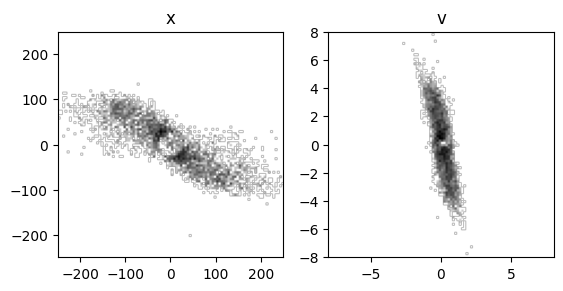

In [64]:
offset = 250
v_offset = 8
fig, ax = plt.subplots(1,2)

hist, xedges, yedges = np.histogram2d(x_stream - com[0], y_stream - com[1], bins=100, 
                                      range=[[-offset, offset], [-offset, offset]])
ax[0].imshow(
hist.T,
origin='lower',
extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
cmap='gray_r',
norm=LogNorm()
)

cov = [np.mean(axis) for axis in v]

hist, xedges, yedges = np.histogram2d(vx_stream - cov[0], vy_stream - cov[1], bins=100, 
                                      range=[[-v_offset, v_offset], [-v_offset, v_offset]])
ax[1].imshow(
hist.T,
origin='lower',
extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
cmap='gray_r',
norm=LogNorm()
)

ax[0].set_title('x')
ax[1].set_title('v')


plt.show()